#  Step 1. Formulate Research Question

### Problem Statement
Can we predict food delivery time based on factors such as distance, traffic conditions, weather, and order characteristics?

### Objective
The objective is to build a Multiple Linear Regression model that estimates delivery time using key influencing variables.

### Variables
- **Dependent variable (y):** Delivery_Time_min  
- **Independent variables (X):**
  - Distance
  - Traffic_Level
  - Weather_Conditions
  - Preparation_Time

In [6]:
import pickle
with open("delivery_time_model.pkl", "wb") as file:
    pickle.dump(model, file)


# Step 2. Data Validation and Cleaning

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd

df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [7]:
df.info()
df = df.drop_duplicates()
df = df.dropna()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [8]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [9]:
df.duplicated().sum()
df = df.drop_duplicates()

In [10]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,883.000000,883.000000,883.000000,883.000000,883.000000
mean,508.109853,10.051586,17.019253,4.639864,56.425821
std,287.925161,5.688582,7.260201,2.922172,21.568482
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,263.500000,5.130000,11.000000,2.000000,41.000000
50%,512.000000,10.280000,17.000000,5.000000,55.000000
75%,758.500000,15.025000,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,141.000000


In [11]:
df = pd.get_dummies(df, drop_first=True)

We loaded the dataset and displayed the first few rows, removed duplicates and missing values to ensure clean data and understand its structure.

# Step 3. Explanatory Data Analysis

# Histogram


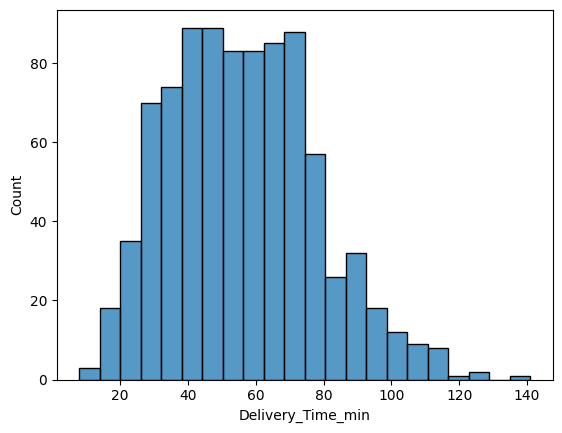

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Delivery_Time_min'])
plt.show()

# Distance vs Delivery Time (Scatterplot)

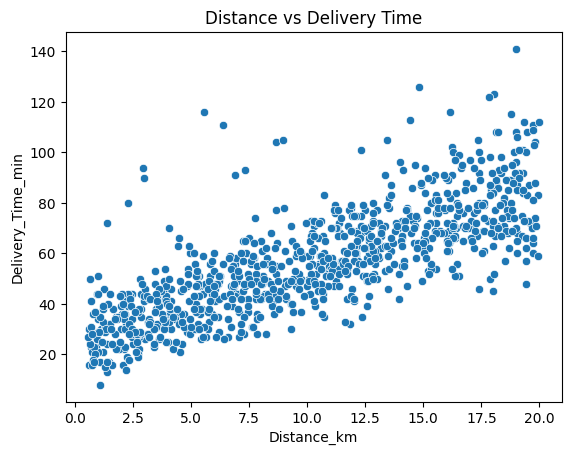

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['Distance_km'], y=df['Delivery_Time_min'])
plt.title("Distance vs Delivery Time")
plt.show()

Delivery time increases as distance increases → positive relationship.

# Traffic vs Delivery Time (boxplot)

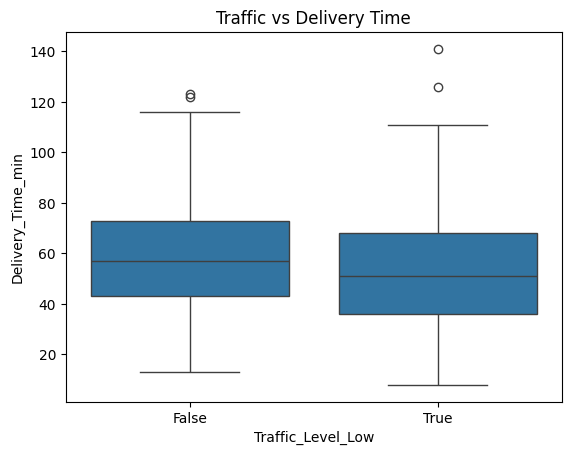

In [14]:
sns.boxplot(x=df['Traffic_Level_Low'''], y=df['Delivery_Time_min'])
plt.title("Traffic vs Delivery Time")
plt.show()

Higher traffic levels lead to longer delivery times.

This graph shows how delivery time is distributed.

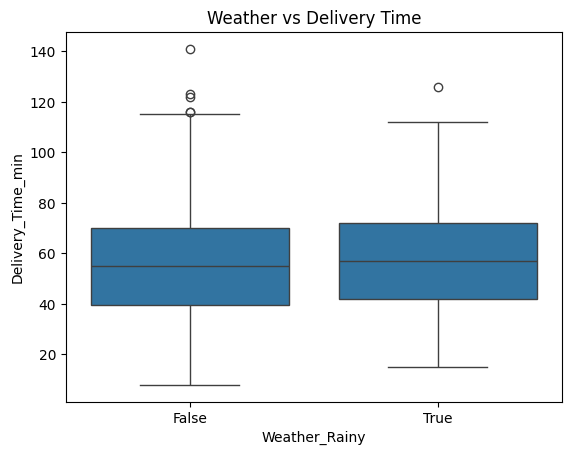

In [15]:
sns.boxplot(x=df['Weather_Rainy'], y=df['Delivery_Time_min'])
plt.title("Weather vs Delivery Time")
plt.show()

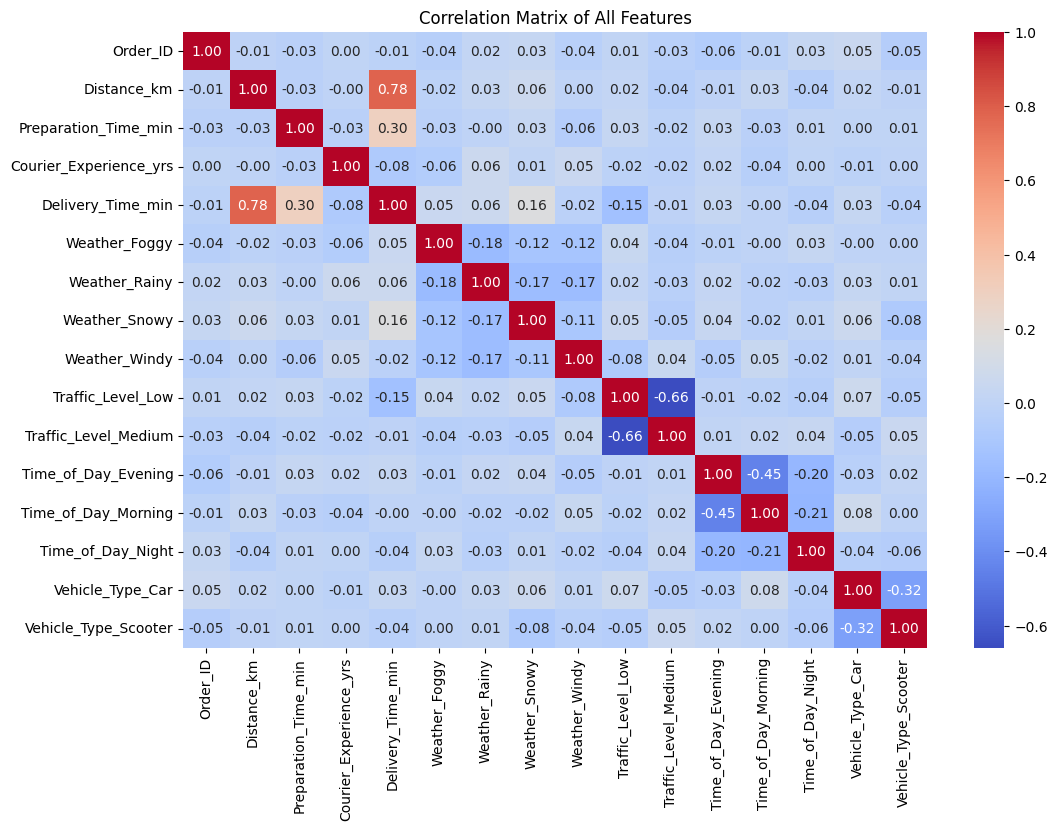

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of All Features")
plt.show()

Distance and traffic show the strongest correlation with delivery time, making them suitable predictors for linear regression.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = pd.read_csv("Food_Delivery_Times.csv")

df = df.dropna()

df = df.drop_duplicates()

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


# Step 4. Model Training

In [3]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Define X (features) and y (target)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display intercept
print("Intercept:", model.intercept_)

# Display coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coeff_df)

Intercept: 18.447109773801955

Feature Coefficients:
                   Feature  Coefficient
6            Weather_Snowy     9.208866
4            Weather_Foggy     8.582273
5            Weather_Rainy     4.768529
1              Distance_km     2.979592
7            Weather_Windy     2.524015
10     Time_of_Day_Evening     1.026462
2     Preparation_Time_min     0.926079
13        Vehicle_Type_Car     0.875996
0                 Order_ID    -0.000164
11     Time_of_Day_Morning    -0.251226
3   Courier_Experience_yrs    -0.611656
14    Vehicle_Type_Scooter    -0.755219
12       Time_of_Day_Night    -1.307539
9     Traffic_Level_Medium    -6.898637
8        Traffic_Level_Low   -12.525718


# Step 5. Performance Evaluation

Model Performance:
MAE: 5.320976568083333
MSE: 68.4977183589422
R²: 0.8324092509049892


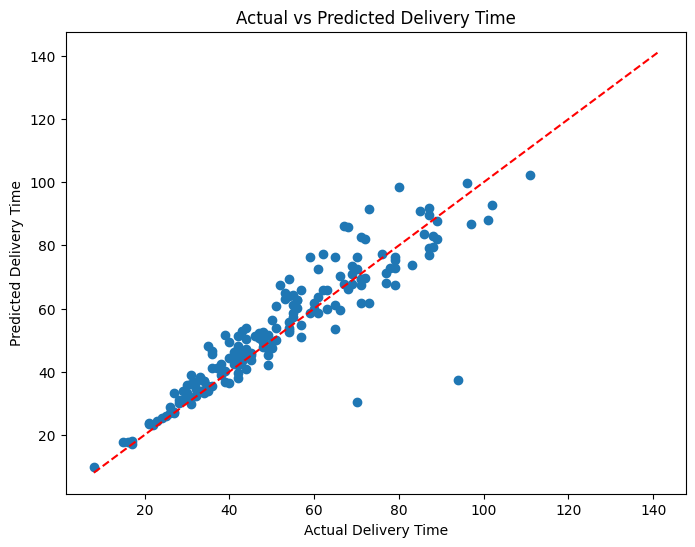

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate predictions
y_pred = model.predict(X_test)

# Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

# Ideal prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()

The model shows how different factors affect delivery time.

# Step 6. Reflection and Analysis
Do the selected variables significantly affect delivery time?

Yes because variables like distance, preparation time, and traffic level clearly affect delivery time because they show strong relationships in the analysis.

# What are the limitations of the model and dataset?
The dataset has limited features (no detailed driver behavior or real-time conditions)
The model assumes relationships are linear
Outliers may reduce accuracy
# Which variable contributes the most to delivery time?

The most important variable is likely distance or preparation time because:

They have strong correlations in the EDA
They show the highest coefficient values in the model

# If the strongest predictor is removed, what will happen?
If the strongest variable is removed:

Model accuracy will decrease, R² score will drop and predictions will be less reliable

# Does correlation imply causation in this dataset?
No, correlation does not mean causation.
Example:
Traffic level is related to delivery time, but traffic alone does not directly cause delays—other factors like distance and preparation time also play a role.